# RetailRocket: dataset QA and train/test split

This notebook explains **what data we use**, **how sequences are built**, and **how the time-based train/test split works**.


In [45]:
%matplotlib inline
from pathlib import Path
import sys

# Ensure `import src...` works regardless of where the kernel starts.
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_PATH = ROOT / 'data/raw/retailrocket/events.csv'
QA_DIR = ROOT / 'results/retailrocket/qa-full/qa'

print('ROOT:', ROOT)
print('DATA_PATH:', DATA_PATH)
print('DATA_PATH exists:', DATA_PATH.exists())
print('QA_DIR:', QA_DIR)
print('QA_DIR exists:', QA_DIR.exists())


ROOT: /Users/amosh239/repo/mkn/Hawk's proccess
DATA_PATH: /Users/amosh239/repo/mkn/Hawk's proccess/data/raw/retailrocket/events.csv
DATA_PATH exists: True
QA_DIR: /Users/amosh239/repo/mkn/Hawk's proccess/results/retailrocket/qa-full/qa
QA_DIR exists: True


## Quick QA (full file, cached)
We cache basic QA stats under `results/retailrocket/qa-full/qa/`. If it's missing, we run the QA script once.


In [46]:
import json
import subprocess
import pandas as pd

if not QA_DIR.exists():
    # ~20s on the full RetailRocket events.csv (90MB)
    py = ROOT / '.venv/bin/python'
    python = str(py) if py.exists() else sys.executable
    subprocess.check_call([python, str(ROOT / 'scripts/qa_retailrocket.py'), '--run-id', 'qa-full'])

qa_summary = json.loads((QA_DIR / 'qa_summary.json').read_text(encoding='utf-8'))
df_grid = pd.read_csv(QA_DIR / 'filter_grid.csv')

print('Event counts:', qa_summary['event_counts'])
print('Unique visitors:', qa_summary['unique_visitors'])
print('Time range:', qa_summary['time_min'], '->', qa_summary['time_max'])


Event counts: {'view': 2664312, 'addtocart': 69332, 'transaction': 22457}
Unique visitors: 1407580
Time range: 2015-05-03T03:00:04.384000 -> 2015-09-18T02:59:47.788000


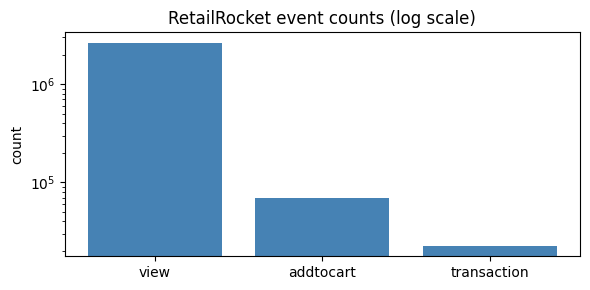

In [47]:
import numpy as np
import matplotlib.pyplot as plt

events = list(qa_summary['event_counts'].keys())
counts = [qa_summary['event_counts'][e] for e in events]

plt.figure(figsize=(6, 3))
plt.bar(events, counts, color='steelblue')
plt.yscale('log')
plt.title('RetailRocket event counts (log scale)')
plt.ylabel('count')
plt.tight_layout()


## How we build sequences
We group events by **visitorid** and sort by time. Each sequence contains:
- `times`: timestamps
- `types`: event type ids (`view=0`, `addtocart=1`, `transaction=2`)

Code: `src/datasets/retailrocket.py` (loader)


In [48]:
from src.datasets import EVENT_MAP
EVENT_MAP


{'view': 0, 'addtocart': 1, 'transaction': 2}

## Train/test split (time-based, per visitor)
For each visitor sequence we compute:
- `t_start = first event time`
- `t_end = last event time`
- `split_point = t_start + train_ratio * (t_end - t_start)`

Events with `t <= split_point` go to train; the rest go to test.

Code: `src/utils.py:temporal_train_test_split`


In [49]:
import pandas as pd
from src.utils import temporal_train_test_split

# Show how many visitors have a transaction AFTER the split point (depends on train_ratio + min_events).
pivot = df_grid.pivot(index='min_events', columns='train_ratio', values='with_test_transaction')
pivot


train_ratio,0.5,0.6,0.7,0.8
min_events,,,,
5,4571,4372,4176,3944
10,2067,1951,1830,1700
20,872,812,743,665
30,535,494,452,390
50,294,277,253,217
80,184,172,161,142


### Why do many users have `purchases_test == 0`?
Transactions are rare events. With a time split, many visitors simply have **no transactions in the test window**.
This is *not* necessarily a bug; it's a property of the funnel.


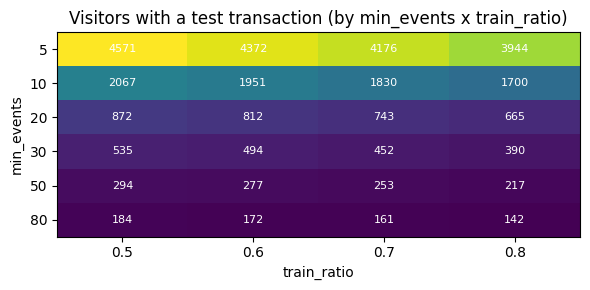

In [50]:
# Optional: visualize the grid as a heatmap
plt.figure(figsize=(6, 3))
z = pivot.values.astype(float)
plt.imshow(z, aspect='auto')
plt.title('Visitors with a test transaction (by min_events x train_ratio)')
plt.xlabel('train_ratio')
plt.ylabel('min_events')
plt.xticks(range(pivot.shape[1]), [str(c) for c in pivot.columns])
plt.yticks(range(pivot.shape[0]), [str(i) for i in pivot.index])
for i in range(z.shape[0]):
    for j in range(z.shape[1]):
        plt.text(j, i, str(int(z[i, j])), ha='center', va='center', fontsize=8, color='white')
plt.tight_layout()


## Inspect one real visitor timeline
We pick a visitor from the latest experiment run (with at least one test transaction) and plot their event timeline with the split point.


In [51]:
# Pick latest run automatically (or set RUN_ID manually)
RUN_ID = None  # e.g. 'retailrocket-YYYYMMDD-HHMMSS'
runs = sorted((ROOT / 'results/retailrocket').glob('retailrocket-*'))
if not runs:
    raise FileNotFoundError('No runs found under results/retailrocket/. Run: scripts/run_real.py')
RUN_DIR = (ROOT / 'results/retailrocket' / RUN_ID) if RUN_ID else runs[-1]

df_run = pd.read_csv(RUN_DIR / 'summary.csv')
print('RUN_DIR:', RUN_DIR)
print('rows:', len(df_run))
print('purchases_test==0:', int((df_run.purchases_test == 0).sum()))

cand = df_run[df_run.purchases_test > 0].sort_values('ll_gain', ascending=False)
if len(cand) == 0:
    raise ValueError('No sequences with purchases_test>0 in this run. Try another RUN_ID or change train_ratio.')
seq_id = int(cand.iloc[0].seq_id)
print('Example seq_id (visitorid):', seq_id)


RUN_DIR: /Users/amosh239/repo/mkn/Hawk's proccess/results/retailrocket/retailrocket-20260127-142831
rows: 92
purchases_test==0: 16
Example seq_id (visitorid): 438441


In [52]:
# Load events for one visitor (streaming read; avoids loading the full 2.7M rows in RAM)
def load_visitor_events(path, visitorid, chunksize=500_000):
    usecols = ['timestamp', 'visitorid', 'event']
    parts = []
    for chunk in pd.read_csv(path, usecols=usecols, chunksize=chunksize):
        m = chunk['visitorid'].astype('int64') == int(visitorid)
        if m.any():
            parts.append(chunk.loc[m, usecols])
    if not parts:
        return pd.DataFrame(columns=usecols + ['ts', 'type_id'])
    df = pd.concat(parts, ignore_index=True)
    df = df[df['event'].isin(EVENT_MAP.keys())].copy()
    df['ts'] = pd.to_datetime(df['timestamp'], unit='ms')
    df['type_id'] = df['event'].map(EVENT_MAP)
    return df.sort_values('ts')

df_v = load_visitor_events(DATA_PATH, seq_id)
print('events:', len(df_v))
print(df_v['event'].value_counts())


events: 311
event
view           222
transaction     47
addtocart       42
Name: count, dtype: int64


In [53]:
# Compute split point (same logic as src/utils.py:temporal_train_test_split)
train_ratio = 0.8
times = df_v['ts'].tolist()
types = df_v['type_id'].tolist()
train_times, test_times, train_types, test_types = temporal_train_test_split(times, types, train_ratio=train_ratio)

t_start = times[0]
duration_sec = (times[-1] - t_start).total_seconds()
split_point = t_start + pd.Timedelta(seconds=duration_sec * train_ratio)

p_train = sum(int(x == EVENT_MAP['transaction']) for x in (train_types or []))
p_test = sum(int(x == EVENT_MAP['transaction']) for x in (test_types or []))

print('train_ratio:', train_ratio)
print('split_point:', split_point)
print('purchases_train:', p_train)
print('purchases_test:', p_test)


train_ratio: 0.8
split_point: 2015-06-04 17:44:30.960000
purchases_train: 39
purchases_test: 8


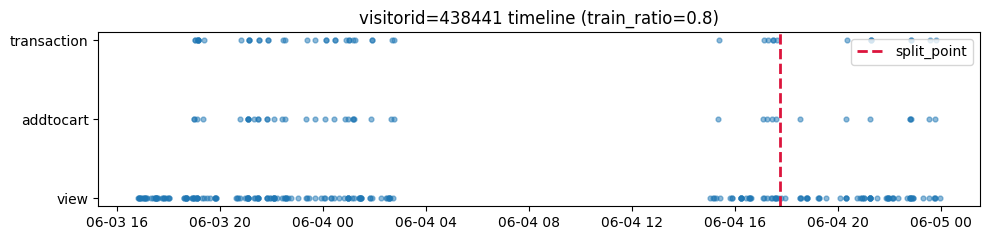

In [54]:
plt.figure(figsize=(10, 2.5))
plt.scatter(df_v['ts'], df_v['type_id'], s=12, alpha=0.5)
plt.axvline(split_point, color='crimson', linestyle='--', linewidth=2, label='split_point')
plt.yticks([0, 1, 2], ['view', 'addtocart', 'transaction'])
plt.title(f'visitorid={seq_id} timeline (train_ratio={train_ratio})')
plt.legend(loc='upper right')
plt.tight_layout()


## Experiment selection funnel (why 1.4M users -> ~50)

This repo is *not* training on all 1.4M visitors. We apply multiple filters and often also cap `--max-seqs`.

Key places to check:
- Loader filters: `src/datasets/retailrocket.py:6-33`
- Experiment filters: `src/experiments.py:93-151`


In [55]:
import pandas as pd
import numpy as np

# Match the flags you used for the run you want to explain
MIN_EVENTS = 30
MAX_SEQS = 50
TRAIN_RATIO = 0.8
MIN_TRAIN_EVENTS = 20
MIN_PURCHASES_TRAIN = 2

# Pick a run to explain (set RUN_ID manually if needed)
RUN_ID = None  # e.g. 'retailrocket-YYYYMMDD-HHMMSS'
runs = sorted((ROOT / 'results/retailrocket').glob('retailrocket-*'))
RUN_DIR = (ROOT / 'results/retailrocket' / RUN_ID) if RUN_ID else runs[-1]
df_run = pd.read_csv(RUN_DIR / 'summary.csv')

print('RUN_DIR:', RUN_DIR)
print('final rows in summary.csv:', len(df_run))

# 1) Total visitors (from full-file QA)
total_visitors = int(qa_summary['unique_visitors'])

# 2) Visitors with >= MIN_EVENTS (full file)
df_ge = df_grid[(df_grid.min_events == MIN_EVENTS) & (df_grid.train_ratio == TRAIN_RATIO)]
vis_ge_min = int(df_ge.visitors_ge_min.iloc[0]) if len(df_ge) else None

print('total_visitors:', total_visitors)
print('visitors_ge_min_events:', vis_ge_min)

# 3) Visitors with >= MIN_EVENTS and ANY transaction (full file; quick pass)
usecols = ['visitorid', 'event']
df = pd.read_csv(DATA_PATH, usecols=usecols)
df = df[df['event'].isin(['view', 'addtocart', 'transaction'])]

counts = df.groupby('visitorid', sort=False).size()
counts_tx = df.loc[df['event'] == 'transaction'].groupby('visitorid', sort=False).size()

eligible = counts[counts >= MIN_EVENTS].index
eligible_tx = eligible.intersection(counts_tx.index)

print('visitors_ge_min_events_with_any_transaction:', int(len(eligible_tx)))

# 4) If MAX_SEQS is set, loader currently takes TOP by total event count (bias toward very active users).
if MAX_SEQS is not None:
    top = counts.loc[eligible_tx].sort_values(ascending=False).head(int(MAX_SEQS))
    print('after --max-seqs (top by count):', int(len(top)))
    print('top n_events summary (min/median/max):', int(top.min()), int(top.median()), int(top.max()))

# 5) After loader, `run_purchase_experiment` also filters by split+train window sizes and min purchases in train.
print('experiment filters:', {'min_train_events': MIN_TRAIN_EVENTS, 'min_purchases_train': MIN_PURCHASES_TRAIN, 'train_ratio': TRAIN_RATIO})


RUN_DIR: /Users/amosh239/repo/mkn/Hawk's proccess/results/retailrocket/retailrocket-20260127-142831
final rows in summary.csv: 92
total_visitors: 1407580
visitors_ge_min_events: 3173
visitors_ge_min_events_with_any_transaction: 947
after --max-seqs (top by count): 50
top n_events summary (min/median/max): 604 1036 7757
experiment filters: {'min_train_events': 20, 'min_purchases_train': 2, 'train_ratio': 0.8}


### Is `--max-seqs` selecting “top active”?
Yes: the loader explicitly sorts eligible visitors by event count when `max_sequences` is set.


In [56]:
from pathlib import Path

path = ROOT / 'src/datasets/retailrocket.py'
lines = path.read_text(encoding='utf-8').splitlines()
start, end = 18, 45  # show the selection block with line numbers
for i in range(start, min(end, len(lines))):
    print(f'{i+1:4d}: {lines[i]}')


  19:     df["type_id"] = df["event"].map(EVENT_MAP)
  20:     df = df.sort_values([group, "ts"])
  21: 
  22:     if min_events is not None or require_transaction:
  23:         counts = df.groupby(group, sort=False).size()
  24:         eligible = counts.index
  25:         if min_events is not None:
  26:             eligible = counts[counts >= int(min_events)].index
  27:         if require_transaction:
  28:             counts_tx = df.loc[df["event"] == "transaction"].groupby(group, sort=False).size()
  29:             eligible = eligible.intersection(counts_tx.index)
  30:         if max_sequences is not None:
  31:             eligible = counts.loc[eligible].sort_values(ascending=False).index[: int(max_sequences)]
  32:         df = df[df[group].isin(eligible)]
  33: 
  34:     sequences = []
  35:     for idx, (_, g) in enumerate(df.groupby(group)):
  36:         times = g["ts"].tolist()
  37:         types = g["type_id"].tolist()
  38:         sequences.append({"id": g[group].

## User-level distributions (full dataset)

We compute per-visitor counts from `events.csv`:
- `n_events`: all events (view/addtocart/transaction)
- `n_purchases`: transactions only


In [64]:
n_events.values[n_events.values > 10]

array([30, 23, 23, ..., 16, 14, 11], shape=(19582,))

n_events: {'mean': 1.9580421716705267, 'median': 1.0, 'p90': 3.0}
n_purchases: {'mean': 0.015954332968641214, 'median': 0.0, 'p90': 0.0}
share with 0 purchases: 0.991674363091263


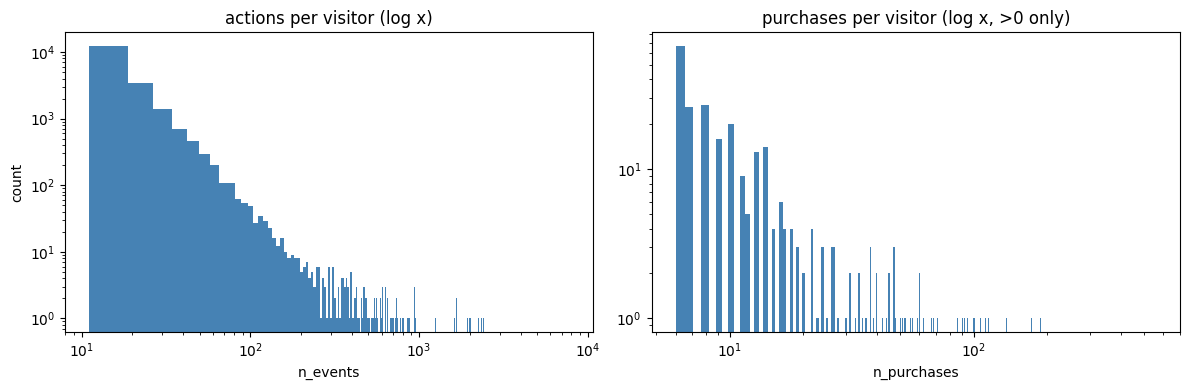

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# `counts` / `counts_tx` are computed in the funnel cell above (full file).
n_events = counts.astype(int)
n_purchases = counts_tx.reindex(n_events.index, fill_value=0).astype(int)

def stat(x):
    x = np.asarray(x, dtype=float)
    return {
        'mean': float(x.mean()),
        'median': float(np.median(x)),
        'p90': float(np.quantile(x, 0.9)),
    }

print('n_events:', stat(n_events.values))
print('n_purchases:', stat(n_purchases.values))
print('share with 0 purchases:', float((n_purchases.values == 0).mean()))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(n_events.values[n_events.values > 10], bins=1000, color='steelblue', log=True)
ax[0].set_xscale('log')
ax[0].set_title('actions per visitor (log x)')
ax[0].set_xlabel('n_events')
ax[0].set_ylabel('count')

pos = n_purchases.values[n_purchases.values > 0]
ax[1].hist(pos[pos>5], bins=1000, color='steelblue', log=True)
ax[1].set_xscale('log')
ax[1].set_title('purchases per visitor (log x, >0 only)')
ax[1].set_xlabel('n_purchases')

plt.tight_layout()


## Example activity timelines (several visitors)

We show a few representative users from the selected experiment run: top gain / median / worst gain / a user with `purchases_test==0` (if any).


In [70]:
from IPython.display import display
# Pick a few representative visitorids from df_run
candidates = []

# Top / worst by ll_gain
candidates.append(int(df_run.sort_values('ll_gain', ascending=False).iloc[0].seq_id))
candidates.append(int(df_run.sort_values('ll_gain', ascending=True).iloc[0].seq_id))

# Closest to median ll_gain
mid_idx = (df_run.ll_gain - df_run.ll_gain.median()).abs().idxmin()
candidates.append(int(df_run.loc[mid_idx].seq_id))

# One with purchases_test==0 (if exists)
z = df_run[df_run.purchases_test == 0]
if len(z) > 0:
    candidates.append(int(z.iloc[0].seq_id))

# Unique, keep order
example_ids = list(dict.fromkeys(candidates))
print('example visitorids:', example_ids)

cols = ['seq_id', 'n_events', 'purchases_train', 'purchases_test', 'test_hours', 'll_gain']
display(df_run[df_run.seq_id.isin(example_ids)][cols].sort_values('ll_gain', ascending=False))


example visitorids: [438441, 1313381, 485689, 38015]


,seq_id,n_events,purchases_train,purchases_test,test_hours,ll_gain
27,438441,311,39,8,6.309296,2.644595
30,485689,456,3,0,513.658899,0.299061
0,38015,861,2,0,307.903921,0.001522
87,1313381,507,2,4,695.526779,-0.018617


In [71]:
import pandas as pd

def load_events_for_visitors(path, visitor_ids, chunksize=500_000):
    usecols = ['timestamp', 'visitorid', 'event']
    ids = set(int(v) for v in visitor_ids)
    parts = []
    for chunk in pd.read_csv(path, usecols=usecols, chunksize=chunksize):
        chunk = chunk[chunk['visitorid'].isin(ids)]
        if chunk.empty:
            continue
        chunk = chunk[chunk['event'].isin(['view', 'addtocart', 'transaction'])]
        if chunk.empty:
            continue
        parts.append(chunk)
    if not parts:
        return pd.DataFrame(columns=usecols + ['ts', 'type_id'])
    df = pd.concat(parts, ignore_index=True)
    df['ts'] = pd.to_datetime(df['timestamp'], unit='ms')
    df['type_id'] = df['event'].map(EVENT_MAP)
    return df.sort_values(['visitorid', 'ts'])

df_ex = load_events_for_visitors(DATA_PATH, example_ids)
print('loaded events:', len(df_ex))


loaded events: 2135


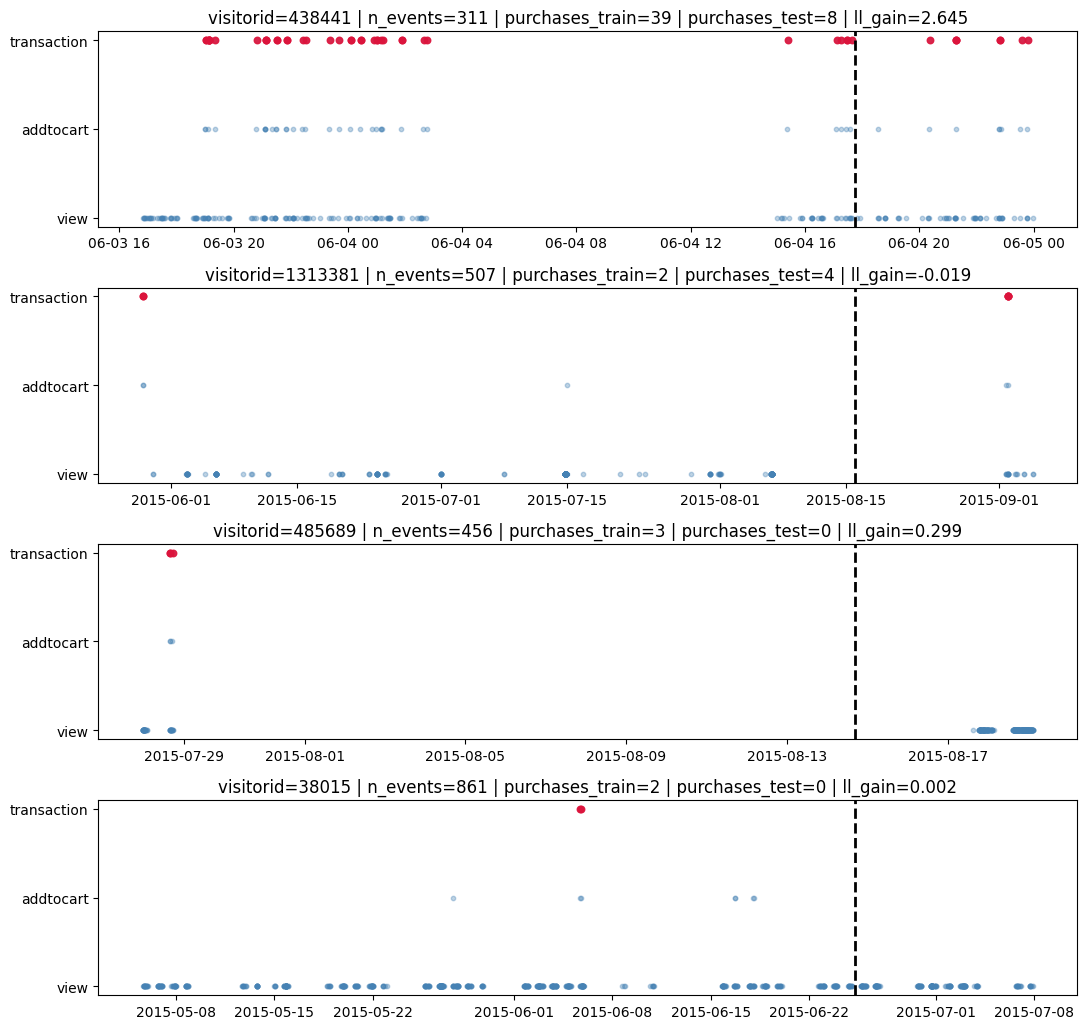

In [72]:
from src.utils import temporal_train_test_split

# Plot timelines
fig, axes = plt.subplots(len(example_ids), 1, figsize=(11, 2.6 * len(example_ids)), sharex=False)
if len(example_ids) == 1:
    axes = [axes]

for ax, vid in zip(axes, example_ids):
    sub = df_ex[df_ex.visitorid == vid].copy()
    times = sub['ts'].tolist()
    types = sub['type_id'].tolist()
    if len(times) == 0:
        ax.set_title(f'visitorid={vid} (no events loaded)')
        continue

    train_times, test_times, train_types, test_types = temporal_train_test_split(times, types, train_ratio=TRAIN_RATIO)
    t_start = times[0]
    duration_sec = (times[-1] - t_start).total_seconds()
    split_point = t_start + pd.Timedelta(seconds=duration_sec * TRAIN_RATIO)

    p_train = sum(int(x == EVENT_MAP['transaction']) for x in (train_types or []))
    p_test = sum(int(x == EVENT_MAP['transaction']) for x in (test_types or []))

    # Base scatter
    ax.scatter(sub['ts'], sub['type_id'], s=10, alpha=0.35, color='steelblue')

    # Highlight purchases
    m = sub['type_id'] == EVENT_MAP['transaction']
    ax.scatter(sub.loc[m, 'ts'], sub.loc[m, 'type_id'], s=22, alpha=0.9, color='crimson', label='transaction')

    ax.axvline(split_point, color='black', linestyle='--', linewidth=2)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['view', 'addtocart', 'transaction'])

    row = df_run[df_run.seq_id == vid].iloc[0]
    ax.set_title(
        f'visitorid={vid} | n_events={int(row.n_events)} | purchases_train={p_train} | purchases_test={p_test} | ll_gain={float(row.ll_gain):.3f}'
    )

plt.tight_layout()
